In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import matplotlib.ticker as mticker
import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 12,    # affects horizontal colorbar ticks
    "ytick.labelsize": 12,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

2.2.3
cuda


## MC topk solutions on simulation

'sm_scores = df[:, -1][:top_K_num]\nprint("first 10:", sm_scores[:10])\nprint("last 10 :", sm_scores[-10:])\nprint("min at index:", np.argmin(sm_scores), "max at index:", np.argmax(sm_scores))'

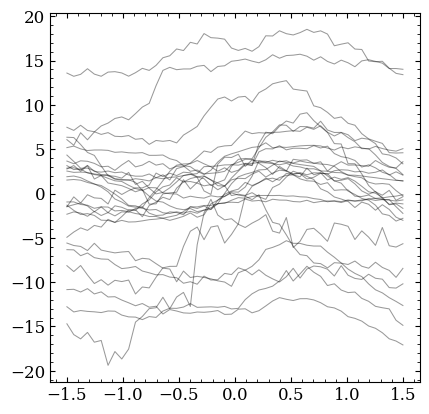

In [3]:
model_types = ['uni_1e7', 'data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']

data_type = 'grad_towards_1e7'

model_dir = f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth'
state_dict = torch.load(model_dir, weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device)
model.eval()

func_type = 'Sine'

input_idx_sim = 4
output_idx_sim = 0
control_indices = [0, 1, 2, 4, 5, 6]

n = 50
x = torch.linspace(-1.5, 1.5, n)
if func_type == 'Parabola':
    y_tgt = x ** 2
elif func_type == 'ReLU':
    m = nn.ReLU()
    y_tgt = m(x)
elif func_type == 'Sigmoid':
    m = nn.Sigmoid()
    y_tgt = m(4*x)
elif func_type == 'Cubic':
    y_tgt = x **3
elif func_type == 'Sine':
    y_tgt = torch.sin(3*x)

sm_scores = []
kmc_scores = []

g_0_sm = []
g_0_kmc = []
p_0_sm = []
p_0_kmc = []

top_K_num = 25
fig, ax = plt.subplots()
I_aff_curves = []
for k in range(0, top_K_num):
    data = np.load(f'/home/hd/hd_hd/hd_gy283/kmc_project/workspaces/my_data_recover/1d_funcs_random_mse/{data_type}_{func_type}_topK/random_mse_func_type={func_type}_data_type={data_type}_topk={k}.npz')
    I_out = data['current']*1e21
    controls = torch.from_numpy(np.delete(data['control'], obj=[output_idx_sim, input_idx_sim], axis=0)).float()
    #print(controls)
    input_tensor = torch.zeros(n, len(control_indices) + 1)
    input_tensor[:, control_indices] = controls.expand(n, -1)
    input_tensor[:, input_idx_sim-1] = x
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_sm = model(input_tensor).detach().cpu().numpy().squeeze()
    
    a_kmc, b_kmc, y_aff_kmc = fit_affine_to_target(torch.from_numpy(I_out), y_tgt)
    a_sm, b_sm, y_aff_sm = fit_affine_to_target(y_sm, y_tgt)
    I_aff_kmc = I_out * a_sm.numpy() + b_sm.numpy()
    #I_aff_kmc = I_out * a_kmc.numpy() + b_kmc.numpy()
    
    sm_scores.append(np.mean((y_aff_sm.numpy() - y_tgt.numpy())**2))
    kmc_scores.append(np.mean((I_aff_kmc - y_tgt.numpy())**2))
    
    ax.plot(np.linspace(-1.5, 1.5, I_out.shape[0]), I_aff_kmc, lw=0.75, alpha=0.4, c='k')
    I_aff_curves.append(I_aff_kmc)
    g_0_sm.append(a_sm)
    g_0_kmc.append(a_kmc)
    p_0_sm.append(b_sm)
    p_0_kmc.append(b_kmc)

#ax.plot(x, y_tgt, color='k', zorder=10)
ax.set_box_aspect(1)
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(direction='in', which='both')
#ax.grid(lw=0.5, alpha=0.5, which='major')

kmc_scores = np.array(kmc_scores)
"""df = pd.read_csv(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO_mse/bayes_opt_affine_data_type={data_type}'
    f'_input_idx=3_func_type={func_type}_lambda_1=0.0__lambda_2=1.0_c_range=1.5.csv'
)
topk = df.nlargest(top_K_num, "target").reset_index(drop=True)
loss_sm = (-topk["target"]).to_numpy()
"""
df = np.loadtxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/'
    f'1d_funcs_random_mse/topK_random_affine_data_type={data_type}_func={func_type}_cmin=-1.5_cmax=1.5_seed=42_maxl2=2.0_input_idx=3_K=100.txt'
)

sm_scores = np.array(sm_scores)
"""sm_scores = df[:, -1][:top_K_num]
print("first 10:", sm_scores[:10])
print("last 10 :", sm_scores[-10:])
print("min at index:", np.argmin(sm_scores), "max at index:", np.argmax(sm_scores))"""

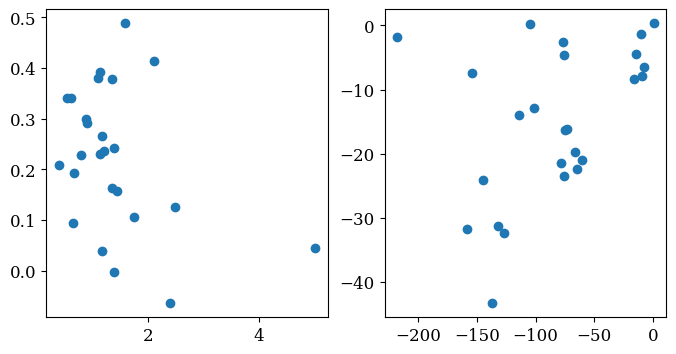

In [35]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].scatter(g_0_sm, g_0_kmc)
ax[1].scatter(p_0_sm, p_0_kmc)

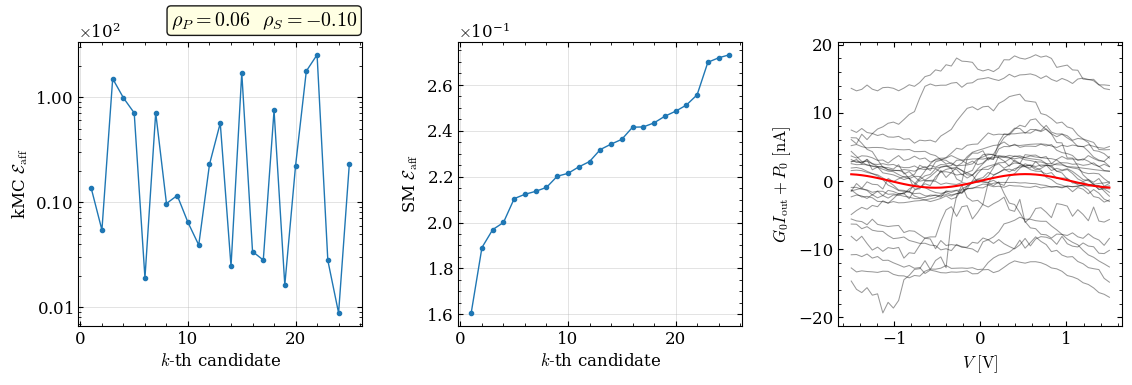

In [4]:
from scipy.stats import spearmanr, pearsonr

ks = np.arange(1, top_K_num+1, 1)

fig, ax = plt.subplots(ncols=3, figsize=(12, 4), constrained_layout=False)

for a in ax:
    a.set_box_aspect(1)
    a.minorticks_on()
    a.tick_params(top=True, right=True, which='both')
    a.tick_params(direction='in', which='both')

ax[0].plot(ks, kmc_scores, marker='o', markersize=3, linewidth=1)
ax[0].set_xlabel("$k$-th candidate")
ax[0].set_ylabel("kMC $\mathcal{E}_{\mathrm{aff}}$")
#ax[0].title("Ground-truth KMC score vs k")
ax[0].grid(lw=0.5, alpha=0.5)
ax[0].set_yscale('log')

ax[1].plot(ks, sm_scores[:top_K_num], marker='o', markersize=3, linewidth=1)
ax[1].set_xlabel("$k$-th candidate")
ax[1].set_ylabel("SM $\mathcal{E}_{\mathrm{aff}}$")
a#x[1].set_title("Surrogate score vs k (from txt)")
ax[1].grid(lw=0.5, alpha=0.5)

def sci_fmt():
    f = mticker.ScalarFormatter(useMathText=True)
    f.set_scientific(True)
    f.set_powerlimits((0, 0))   # force scientific notation
    return f

ax[0].yaxis.set_major_formatter(sci_fmt())
ax[1].yaxis.set_major_formatter(sci_fmt())

"""ax[2].scatter(sm_scores, kmc_scores, s=18)"""
sp = spearmanr(sm_scores, kmc_scores).statistic
pr = pearsonr(sm_scores, kmc_scores).statistic

"""ax[2].text(
    0.10, 0.9, "My text",
    transform=ax[2].transAxes,
    ha="left", va="top"
)
ax[2].xaxis.set_major_formatter(sci_fmt())
ax[2].yaxis.set_major_formatter(sci_fmt())

ax[2].tick_params(top=True, labelbottom=False, right=True, labelleft=False, labeltop=True, labelright=True)
ax[2].xaxis.set_label_position('bottom')
ax[2].yaxis.set_label_position('right')
ax[2].set_xlabel("kMC $\mathcal{E}_{\mathrm{aff}}$")
ax[2].set_ylabel("SM $\mathcal{E}_{\mathrm{aff}}$")"""

for y in I_aff_curves:
    ax[2].plot(x, y, alpha=0.4, lw=0.75, c='k')

ax[2].plot(x, y_tgt, c='r', lw=1.5)

#ax[2].tick_params(labelleft=False, labelright=True)
#ax[2].yaxis.set_label_position('right')
ax[2].set_xlabel('$V \, \, [\mathrm{V}]$')
ax[2].set_ylabel('$G_0 I_{\mathrm{out}} + P_0 \, \, [\mathrm{nA}]$')

#fig. subplots_adjust(wspace=0.3)

fig.suptitle(
    y=0.94, 
    t=f"$\\rho_{{P}}={pr:.2f}$  $\\rho_{{S}}={sp:.2f}$", 
    ha='right', 
    x=0.325,
    bbox=dict(
        facecolor="lightyellow",
        edgecolor="black",
        boxstyle="round,pad=0.2",
        alpha=0.9,
    ),
)
fig.subplots_adjust(left=0.06, right=0.995, bottom=0.15, top=0.86, wspace=0.05)
#fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.45, hspace=-0.0, wspace=0.0)
plt.savefig(f'{data_type}_{func_type}_topk_scores_evaluation.pdf')
plt.show()

Spearman (rank corr): 0.11153846153846154
Pearson  (linear corr): 0.10012911803572119


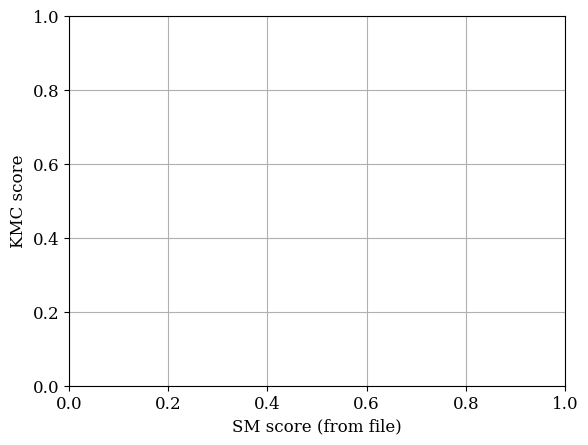

In [32]:


sm_use = sm_scores[:top_K_num]
kmc_use = kmc_scores[:top_K_num]

fig, ax = plt.subplots()

ax.set_xlabel("SM score (from file)")
ax.set_ylabel("KMC score")
#ax.title("Surrogate score vs Ground-truth score")
ax.grid(True)

sp = spearmanr(sm_use, kmc_use).statistic
pr = pearsonr(sm_use, kmc_use).statistic
print("Spearman (rank corr):", sp)
print("Pearson  (linear corr):", pr)

plt.show()